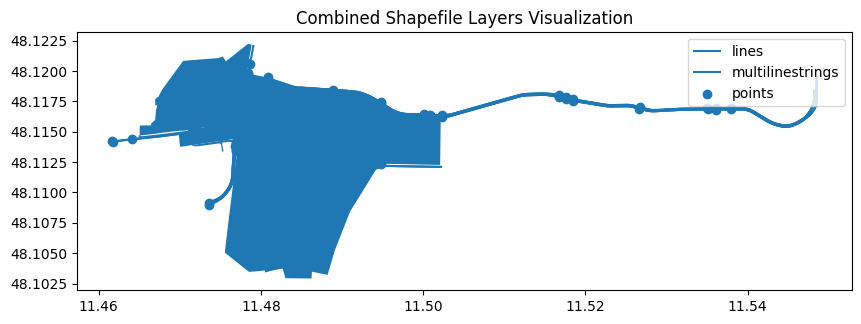

In [3]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 定义文件路径
file_paths = [
    "lines.shp",
    "multilinestrings.shp",
    "multipolygons.shp",
    "points.shp"
]

# 加载和绘制每个图层
fig, ax = plt.subplots(figsize=(10, 10))

# 使用不同的颜色绘制每个图层
for file_path in file_paths:
    gdf = gpd.read_file('C:\\Users\\kangs\\Downloads\\3751e842-3ff9-4430-8f23-0bd9ee03da41\\converted.shp\\'+file_path)
    gdf.plot(ax=ax, label=file_path.split('.')[0])

# 添加图例和标题
ax.legend()
ax.set_title("Combined Shapefile Layers Visualization")
plt.show()


In [8]:
gdf.head()

,osm_id,name,barrier,highway,ref,address,is_in,place,man_made,other_tags,geometry
0,26778910,None,None,None,None,None,None,None,None,"""TMC:cid_58:tabcd_1:Class""=>""Point"",""TMC:cid_5...",POINT (11.47718 48.11549)
1,27331092,None,None,traffic_signals,None,None,None,None,None,None,POINT (11.49479 48.11742)
2,27331109,None,None,crossing,None,None,None,None,None,"""button_operated""=>""no"",""crossing""=>""traffic_s...",POINT (11.48082 48.11954)
3,60338757,Westpark,None,None,1,None,None,None,None,"""description""=>""Westpark, Gleis 2, U6 Richtung...",POINT (11.51668 48.11785)
4,73736211,Harras,None,None,1,None,None,None,None,"""description""=>""U6 Harras"",""layer""=>""-2"",""leve...",POINT (11.53794 48.11683)


In [10]:
non_point_gdf = gdf[gdf.geom_type != "Point"]
print(non_point_gdf.head())


Empty GeoDataFrame
Columns: [osm_id, name, barrier, highway, ref, address, is_in, place, man_made, other_tags, geometry]
Index: []


In [11]:
print(gdf.geom_type.value_counts())

Point    498
Name: count, dtype: int64


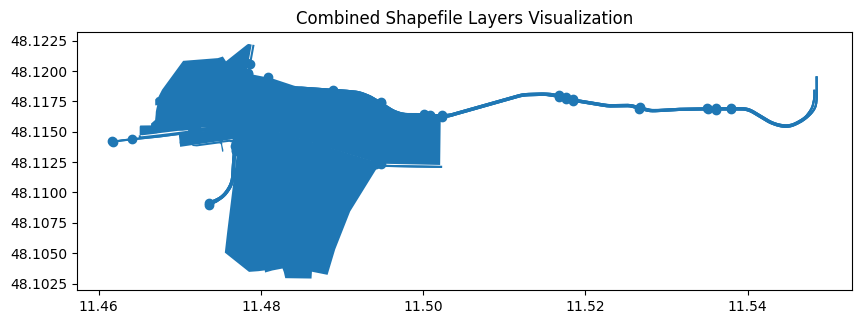

In [13]:
import geopandas as gpd
import matplotlib.pyplot as plt
import os
import pandas as pd
# 定义文件夹路径和文件列表
folder_path = 'C:\\Users\\kangs\\Downloads\\3751e842-3ff9-4430-8f23-0bd9ee03da41\\converted.shp\\'
file_paths = [
    "lines.shp",
    "multilinestrings.shp",
    "multipolygons.shp",
    "points.shp"
]

# 加载每个 .shp 文件并将它们存储在一个列表中
gdfs = [gpd.read_file(os.path.join(folder_path, file_path)) for file_path in file_paths]

# 使用 concat 将所有 GeoDataFrame 合并到一个 GeoDataFrame
combined_gdf = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True))

# 绘制合并后的 GeoDataFrame
fig, ax = plt.subplots(figsize=(10, 10))
combined_gdf.plot(ax=ax)

# 添加标题
ax.set_title("Combined Shapefile Layers Visualization")
plt.show()


In [18]:
# 筛选 Polygon 类型的数据
non_point_gdf = combined_gdf[combined_gdf.geom_type == "Polygon"]

# 保存为 CSV 文件
non_point_gdf.to_csv("non_point_data.csv", index=False)
print("Data saved to non_point_data.csv")



Data saved to non_point_data.csv
